<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/EDA%20%26%20Feature%20Engineering/All_feat_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#from sklearn.svm import SVC
#from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression



In [ ]:
# read dataset
html_df = pd.read_csv("HTML_All_Features.csv")

In [ ]:
# define needed functions to test the model and compare evaluation results between each experiment
def get_models():
    models = {
        "LR": LogisticRegression(),
        "RF": RandomForestClassifier(),
        "XGB": XGBClassifier(),
        #"KNN": KNeighborsClassifier(),
       # "SVM": SVC(),
    }
    return models
def evaluate_models(X_train, X_test, y_train, y_test, experiment_name="experiment"):
    """Trains all 3 models and returns a results DataFrame with metrics for each."""
    models = get_models()
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results.append({
            "Experiment": experiment_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='macro'),
            "Recall": recall_score(y_test, y_pred, average='macro'),
            "F1": f1_score(y_test, y_pred, average='macro')
        })
    return pd.DataFrame(results)

def run_experiment(df_input, feature_list, label_col='label', experiment_name="experiment", test_size=0.3):
    """Full pipeline: split data, train, evaluate — given a dataframe and feature list."""
    X = df_input[feature_list]
    y = df_input[label_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    return evaluate_models(X_train, X_test, y_train, y_test, experiment_name)

def compare_experiments(*result_dfs):
    """Stacks multiple experiment result DataFrames into one combined comparison table."""
    combined = pd.concat(result_dfs, ignore_index=True)
    return combined.pivot(index='Model', columns='Experiment')

    def get_models():
      return{

        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

        "XGBoost": XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),

        "Logistic Regression L1": LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=1000,
            random_state=42
        )

      }

# Exploratory Data Analysis (EDA)

In [ ]:
print("Shape:", html_df.shape)
print("Data Columns:", html_df.info())
print('First rows:')
html_df.head()

Shape: (19997, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19997 entries, 0 to 19996
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   file_size                 19997 non-null  int64  
 1   line_count                19997 non-null  int64  
 2   entropy                   19997 non-null  float64
 3   script_entropy            19997 non-null  float64
 4   tag_count                 19997 non-null  int64  
 5   unique_tag_count          19997 non-null  int64  
 6   script_count              19997 non-null  int64  
 7   form_count                19997 non-null  int64  
 8   iframe_count              19997 non-null  int64  
 9   hidden_iframe_count       19997 non-null  int64  
 10  external_links_count      19997 non-null  int64  
 11  mailto_link_count         19997 non-null  int64  
 12  base64_string_count       19997 non-null  int64  
 13  html_comment_count        19997 non-null  

,file_size,line_count,entropy,script_entropy,tag_count,unique_tag_count,script_count,form_count,iframe_count,hidden_iframe_count,...,object_tag_count,url_digit_count,url_punct_char_count,url_avg_length,url_avg_subdomain_count,hostname_digit_ratio_avg,min_link_length,max_link_length,file_path,label
0,2014,49,5.252908,4.802471,20,12,1,1,0,0,...,0,0,8,15.750000,0.000000,0.000000,14,18,/content/drive/MyDrive/UNB/Mastercard project/...,1
1,177022,3970,4.720787,4.634752,875,13,5,0,0,0,...,0,1139,1033,13.724706,0.061176,0.000000,7,82,/content/drive/MyDrive/UNB/Mastercard project/...,0
2,191188,3088,5.149307,5.371950,1107,33,51,3,0,0,...,0,845,3064,55.930514,1.223565,0.000697,1,132,/content/drive/MyDrive/UNB/Mastercard project/...,0
3,56968,2319,4.726188,4.431225,886,22,11,1,0,0,...,0,1149,1701,26.518310,0.028169,0.000000,1,68,/content/drive/MyDrive/UNB/Mastercard project/...,0
4,167,6,5.052407,0.000000,4,4,0,0,0,0,...,0,0,0,0.000000,0.000000,0.000000,0,0,/content/drive/MyDrive/UNB/Mastercard project/...,1


In [ ]:
#ٍstatistical summary
html_df.describe().T

,count,mean,std,min,25%,50%,75%,max
file_size,19997.0,90430.027904,184499.476801,95.000000,7370.000000,33594.000000,95833.000000,7.514700e+06
line_count,19997.0,1419.262039,2795.851087,0.000000,165.000000,590.000000,1806.000000,9.412900e+04
entropy,19997.0,5.166407,0.387730,0.914438,4.991718,5.179042,5.354134,7.874702e+00
script_entropy,19997.0,4.116942,2.050831,0.000000,4.356263,5.042327,5.366036,6.274234e+00
tag_count,19997.0,483.913637,984.328387,3.000000,57.000000,182.000000,600.000000,4.359100e+04
unique_tag_count,19997.0,24.066710,11.336430,3.000000,16.000000,24.000000,32.000000,2.470000e+02
script_count,19997.0,13.837126,19.027339,0.000000,2.000000,7.000000,19.000000,3.530000e+02
form_count,19997.0,1.319648,2.833063,0.000000,0.000000,1.000000,2.000000,1.890000e+02
iframe_count,19997.0,0.358654,1.059911,0.000000,0.000000,0.000000,0.000000,2.700000e+01
hidden_iframe_count,19997.0,0.158274,0.428065,0.000000,0.000000,0.000000,0.000000,8.000000e+00


Data check to ensure the dataset is balanced and free of missing or duplicate

In [ ]:
#Inspect calss balance
print(html_df["label"].value_counts())
print(html_df['label'].value_counts(normalize=True))

# Checking for missing values in each column
print("Missing values per column:")
missing = html_df.isnull().sum()
print(missing[missing > 0])

label
1    9999
0    9998
Name: count, dtype: int64
label
1    0.500025
0    0.499975
Name: proportion, dtype: float64
Missing values per column:
Series([], dtype: int64)


In [ ]:
feature_cols = html_df.columns.drop(['file_path', 'label'])

#Duplicate rows (based on features only)
print("Feature-only duplicate rows", html_df.duplicated(subset=feature_cols).sum())

dupe_rows = html_df[html_df.duplicated(subset=feature_cols, keep=False)]
print("Total rows involved in duplicate groups:", dupe_rows.shape[0])

#Duplicate group sizes
group_sizes = dupe_rows.groupby(list(feature_cols)).size()
print("\nNumber of distinct duplicate groups:", len(group_sizes))
print("Group size distribution:")
print(group_sizes.value_counts().sort_index())

# Check if duplicated feature rows have conflicting labels
group_label_nunique = html_df.groupby(list(feature_cols))['label'].nunique()
print("\nGroups with conflicting labels:", (group_label_nunique > 1).sum())

#Class balance within duplicated rows
print("\nLabel distribution among duplicated rows:")
print(dupe_rows['label'].value_counts())

Feature-only duplicate rows 4587
Total rows involved in duplicate groups: 5683

Number of distinct duplicate groups: 1096
Group size distribution:
2      511
3      171
4      111
5       72
6       42
7       34
8       20
9       29
10      21
11       7
12       5
13       5
14       6
15       6
16       5
17       6
18       2
19       5
20       3
21       1
22       1
23       4
24       1
25       1
26       2
28       2
29       1
30       4
32       2
34       1
36       1
39       1
42       1
51       2
52       1
55       1
60       1
61       1
62       1
64       1
73       1
74       1
94       1
121      1
Name: count, dtype: int64

Groups with conflicting labels: 6

Label distribution among duplicated rows:
label
1    5249
0     434
Name: count, dtype: int64


In [ ]:
print('\nRows with suspiciously tiny tag_count but large file size:')
print(html_df[(html_df['tag_count']<5)& (html_df['file_size']>100000)].shape[0],'such rows')


Rows with suspiciously tiny tag_count but large file size:
146 such rows


In [ ]:
#Find dead and near-dead feature columns based on value frequency
dead_cols = html_df[feature_cols].columns[html_df[feature_cols].nunique() == 1]

print(f"Fully dead columns ({len(dead_cols)}):")
for col in dead_cols:
    print(f"  {col}  -> constant value: {html_df[col].unique()[0]}")

print("\nNear-dead columns (>99% same value):")
for col in feature_cols:
    top_freq = html_df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.99 and col not in dead_cols:
        print(f"  {col}  -> {top_freq:.2%} of rows are '{html_df[col].mode()[0]}'")


Fully dead columns (0):

Near-dead columns (>99% same value):
  object_tag_count  -> 99.34% of rows are '0'


In [ ]:
#Confirms that both columns match exactly in every row
(html_df["external_link_count"]== html_df["external_links_count"]).all()

np.True_

In [ ]:
#ٌRemoves external_links_coun since it's an exact duplicate of external_link_count
html_df.drop(columns=["external_links_count"],inplace=True)

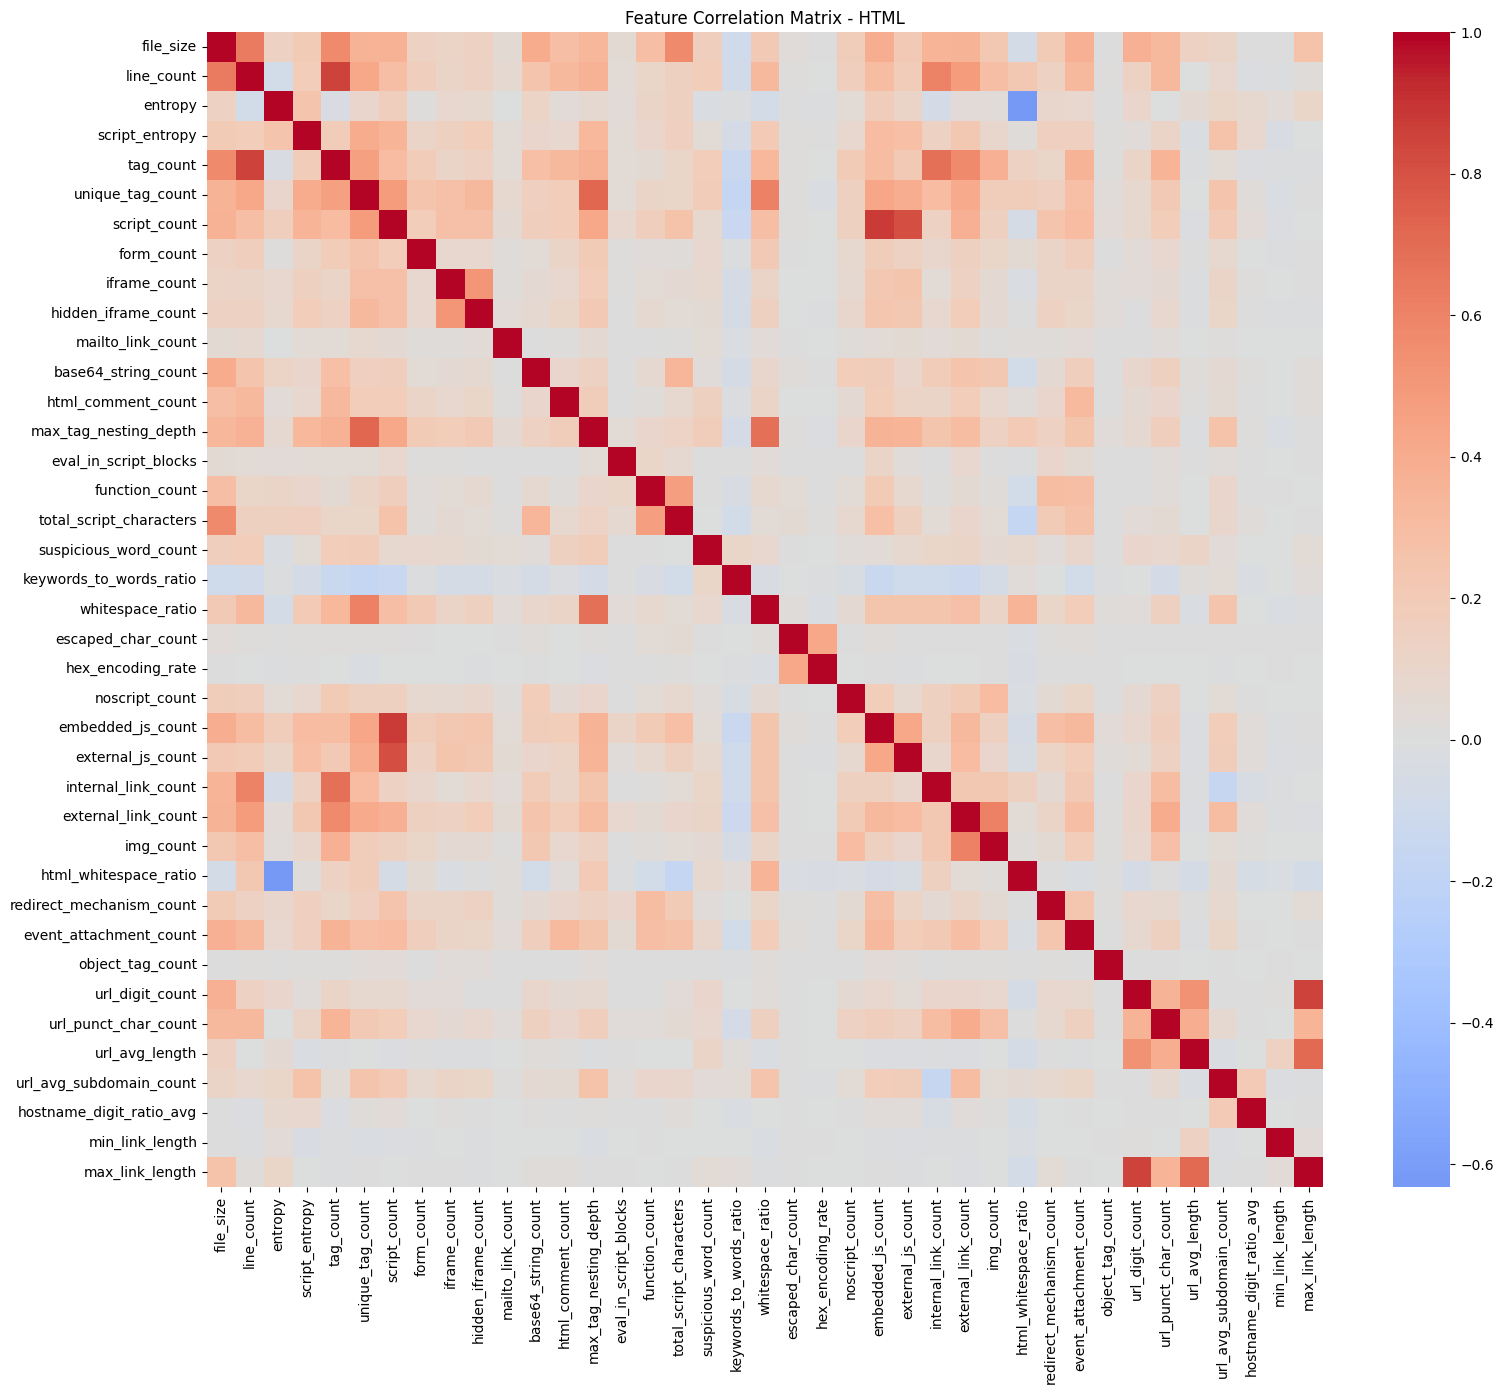

In [ ]:
corr = html_df.drop(columns=["label", "file_path"]).corr()
#corr = clean_df.drop(columns=["label", "file_path"]).corr()
plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix - HTML")
plt.show()

**Data Analysis summary**
- 19,997 rows × 42 columns, no missing values.
- No full-row duplicates, but 4587 duplicate feature rows (6 with conflicting labels)
- Target is balanced (~50/50 benign vs malicious).
 - No fully dead columns, but object_tag_count and eval_in_script_blocks are near-constant
- external_link_count duplicates external_links_count.
- 146 rows show tiny tag_count with large file_size (possible hidden/obfuscated content)


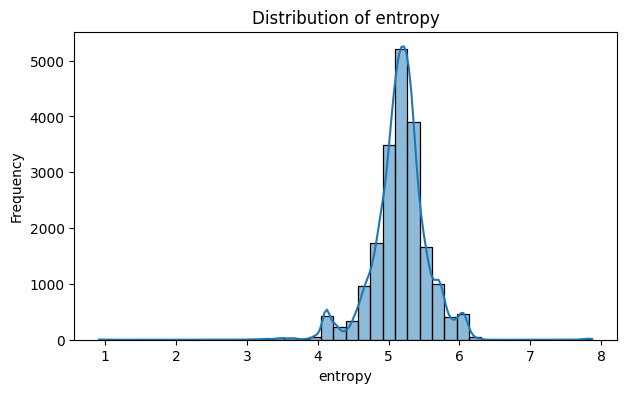

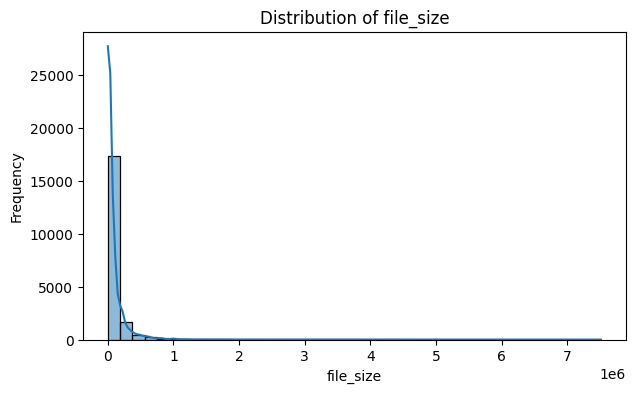

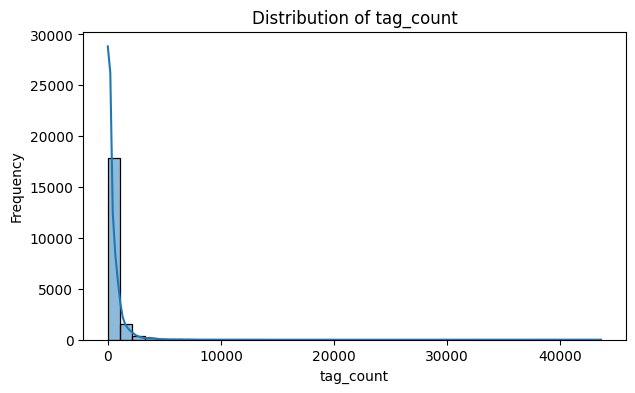

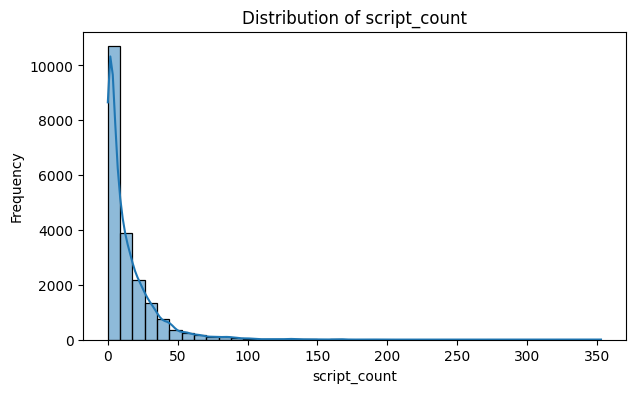

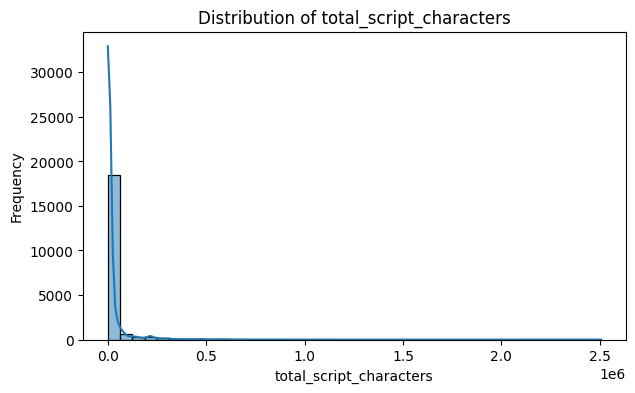

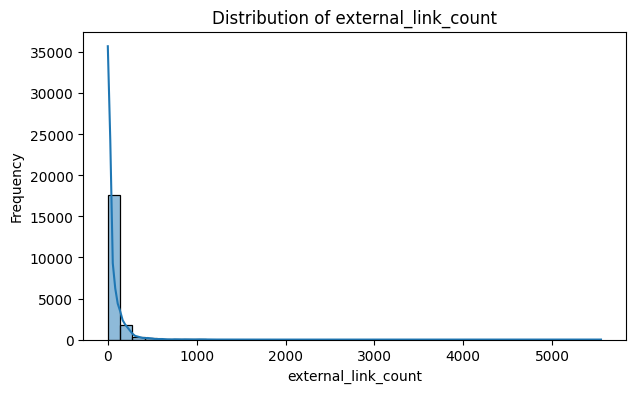

In [ ]:
features = [
    "entropy",
    "file_size",
    "tag_count",
    "script_count",
    "total_script_characters",
    "external_link_count"
]

for feature in features:
    plt.figure(figsize=(7,4))

    sns.histplot(
        html_df[feature],
        bins=40,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

In [ ]:
html_df.nunique()

,0
file_size,13622
line_count,4471
entropy,15410
script_entropy,12203
tag_count,2386
unique_tag_count,73
script_count,158
form_count,42
iframe_count,17
hidden_iframe_count,8


In [ ]:
feature_cols = html_df.columns.drop(['file_path', 'label'])

duplicate_mask = html_df.duplicated(subset=feature_cols, keep=False)
duplicate_rows = html_df[duplicate_mask]

print("Number of duplicates", duplicate_rows.shape[0])
group_sizes = duplicate_rows.groupby(list(feature_cols)).size()
duplicate_rows[['file_path', 'label']].to_csv("html_duplicate_rows_log.csv", index=False)
#print("save the dublicate in file html_duplicate_rows_log.csv")
print(group_sizes.value_counts().sort_index())


print(duplicate_rows[['file_path', 'label']].head(10))

Number of duplicates 5683
2      511
3      171
4      111
5       72
6       42
7       34
8       20
9       29
10      21
11       7
12       5
13       5
14       6
15       6
16       5
17       6
18       2
19       5
20       3
21       1
22       1
23       4
24       1
25       1
26       2
28       2
29       1
30       4
32       2
34       1
36       1
39       1
42       1
51       2
52       1
55       1
60       1
61       1
62       1
64       1
73       1
74       1
94       1
121      1
Name: count, dtype: int64
                                            file_path  label
0   /content/drive/MyDrive/UNB/Mastercard project/...      1
9   /content/drive/MyDrive/UNB/Mastercard project/...      0
10  /content/drive/MyDrive/UNB/Mastercard project/...      1
14  /content/drive/MyDrive/UNB/Mastercard project/...      1
16  /content/drive/MyDrive/UNB/Mastercard project/...      1
22  /content/drive/MyDrive/UNB/Mastercard project/...      1
26  /content/drive/MyDrive/UNB/Master

In [ ]:


#Detect exactly duplicated feature columns

feature_df = html_df.drop(columns=["label"])

duplicate_columns = []

for i, col1 in enumerate(feature_df.columns):
    for col2 in feature_df.columns[i + 1:]:
        if feature_df[col1].equals(feature_df[col2]):
            duplicate_columns.append((col1, col2))

print("Number of duplicated column pairs:", len(duplicate_columns))
display(duplicate_columns)

Number of duplicated column pairs: 0


[]

In [ ]:
#  file_paths for a couple of duplicate groups

sample_group = duplicate_rows.sort_values(by=list(feature_cols)).head(20)

sample_group[['file_path', 'label', 'entropy', 'tag_count', 'file_size']]


,file_path,label,entropy,tag_count,file_size
1745,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
2900,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
5400,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
6242,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
6754,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
10213,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
16422,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
17368,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
17496,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.499935,3,95
1349,/content/drive/MyDrive/UNB/Mastercard project/...,1,4.400836,3,99


In [ ]:
feature_cols = html_df.columns.drop(['file_path', 'label'])
html_df = html_df.dropna(subset=['label', 'file_path'])
clean_df = html_df.drop_duplicates(subset=feature_cols, keep='first') # keep only the first copy of a group

print("Before dedup:", html_df.shape)
print("After dedup:", clean_df.shape)
print("\nClass balance after dedup:")
print(clean_df['label'].value_counts())
print(clean_df['label'].value_counts(normalize=True))# Compute the correlation matrix


Before dedup: (19997, 41)
After dedup: (15410, 41)

Class balance after dedup:
label
0    9621
1    5789
Name: count, dtype: int64
label
0    0.624335
1    0.375665
Name: proportion, dtype: float64


In [ ]:
clean_df.columns

Index(['file_size', 'line_count', 'entropy', 'script_entropy', 'tag_count',
       'unique_tag_count', 'script_count', 'form_count', 'iframe_count',
       'hidden_iframe_count', 'mailto_link_count', 'base64_string_count',
       'html_comment_count', 'max_tag_nesting_depth', 'eval_in_script_blocks',
       'function_count', 'total_script_characters', 'suspicious_word_count',
       'keywords_to_words_ratio', 'whitespace_ratio', 'escaped_char_count',
       'hex_encoding_rate', 'noscript_count', 'embedded_js_count',
       'external_js_count', 'internal_link_count', 'external_link_count',
       'img_count', 'html_whitespace_ratio', 'redirect_mechanism_count',
       'event_attachment_count', 'object_tag_count', 'url_digit_count',
       'url_punct_char_count', 'url_avg_length', 'url_avg_subdomain_count',
       'hostname_digit_ratio_avg', 'min_link_length', 'max_link_length',
       'file_path', 'label'],
      dtype='object')

In [ ]:
# Compare evaluation results between full dataset and clean dataset
baseline = run_experiment(html_df, feature_cols, experiment_name="Raw Data")
clean_result = run_experiment(clean_df, feature_cols, experiment_name="Clean Data")
#comparison = compare_experiments(baseline, clean_result)
##print(comparison)
print(compare_experiments(baseline))

print(compare_experiments(clean_result))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

            Accuracy Precision    Recall        F1
Experiment  Raw Data  Raw Data  Raw Data  Raw Data
Model                                             
LR          0.582833  0.670806  0.582833  0.521180
RF          0.937000  0.937070  0.937000  0.936997
XGB         0.940167  0.940167  0.940167  0.940167
             Accuracy  Precision     Recall         F1
Experiment Clean Data Clean Data Clean Data Clean Data
Model                                                 
LR           0.664071   0.717020   0.561331   0.516172
RF           0.910231   0.907290   0.900253   0.903512
XGB          0.921480   0.918402   0.913502   0.915827


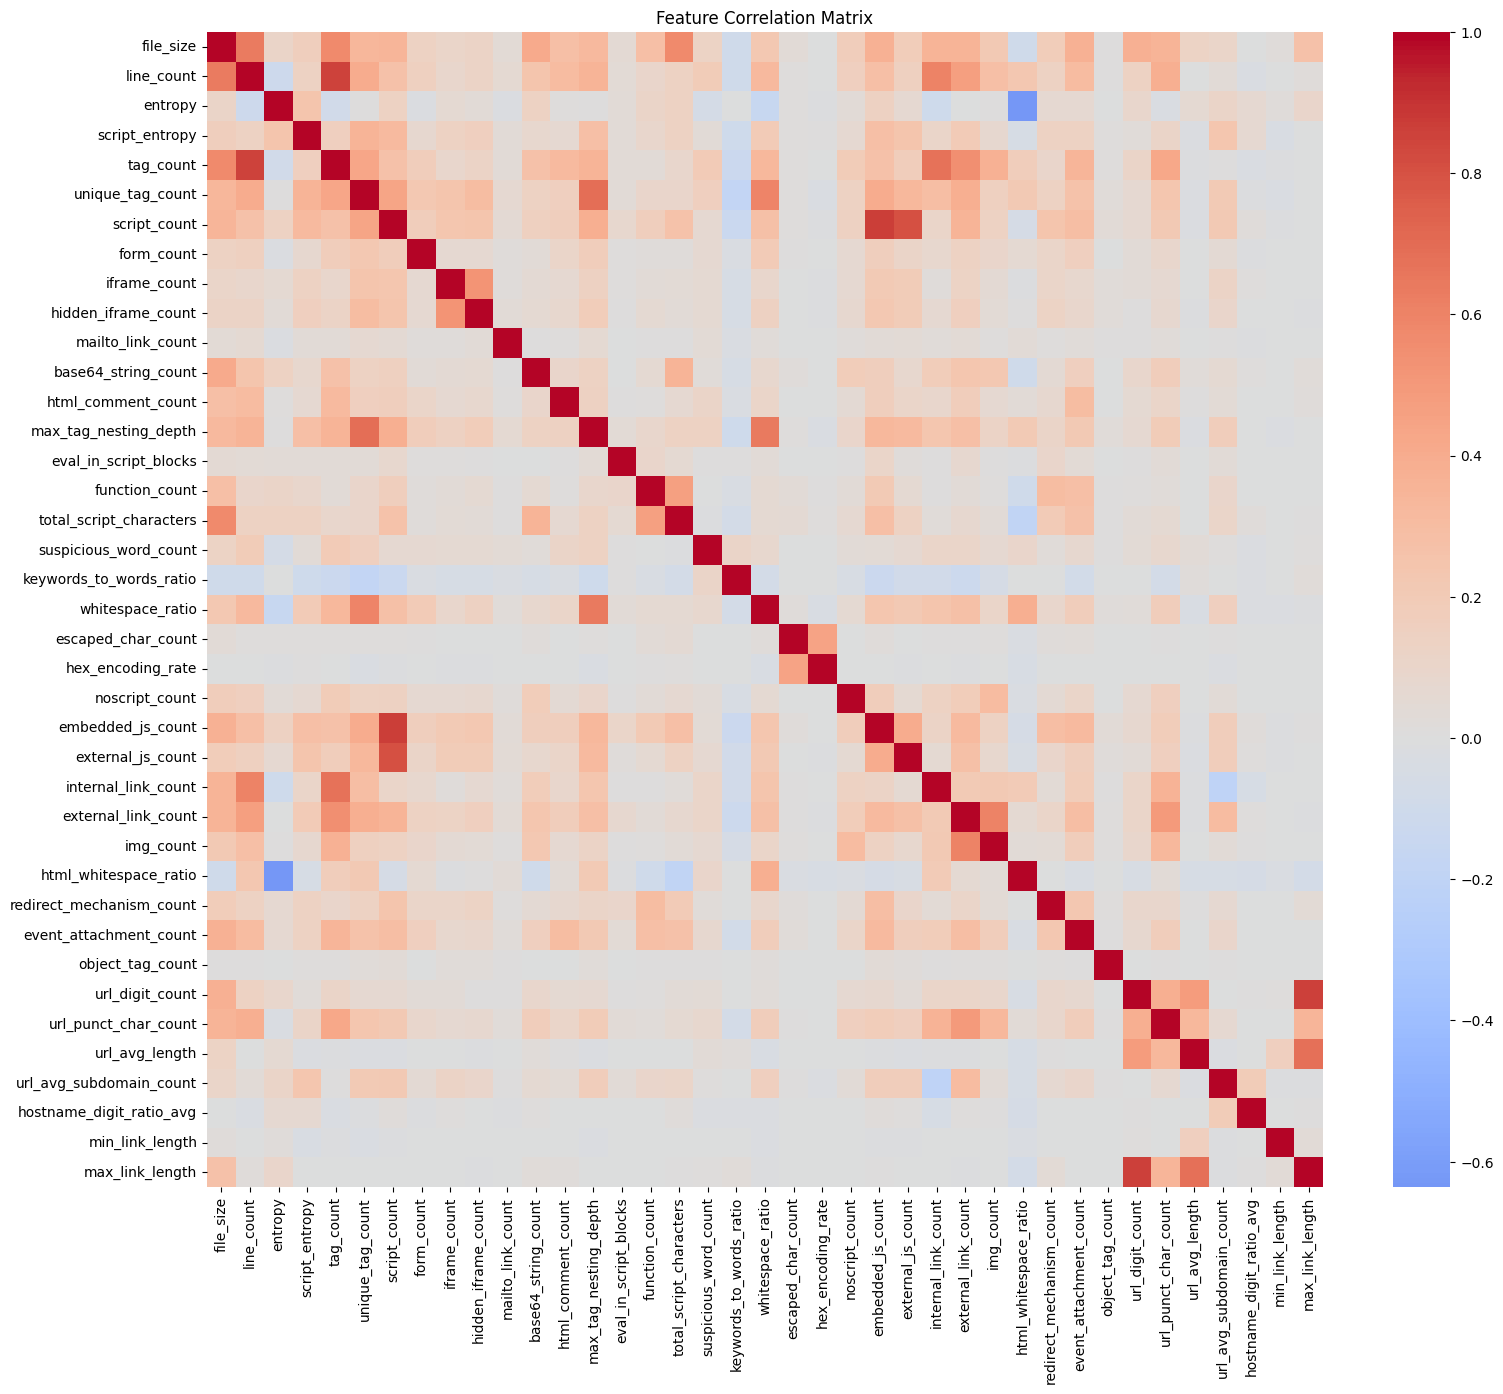

In [ ]:
 #Compute the correlation matrix on the clean dataset
corr = clean_df.drop(columns=["file_path","label"]).corr()

plt.figure(figsize=(18, 15))

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# The Correlation of all features with the label
feature_cols =html_df.columns.drop(['file_path', 'label'])

correlations = html_df[feature_cols].corrwith(html_df['label']).sort_values(key=abs, ascending=False)
print(correlations.head(15))
print(correlations.tail(15))

unique_tag_count          -0.464796
script_count              -0.379365
embedded_js_count         -0.345438
tag_count                 -0.312349
script_entropy            -0.311823
external_link_count       -0.310541
external_js_count         -0.291105
whitespace_ratio          -0.266167
max_tag_nesting_depth     -0.266163
keywords_to_words_ratio    0.266079
line_count                -0.253761
hidden_iframe_count       -0.243131
internal_link_count       -0.232392
file_size                 -0.216331
event_attachment_count    -0.186054
dtype: float64
mailto_link_count          -0.083633
form_count                 -0.076650
function_count             -0.070580
html_whitespace_ratio      -0.068187
suspicious_word_count      -0.065516
max_link_length             0.045230
url_avg_length              0.035520
eval_in_script_blocks      -0.023235
object_tag_count           -0.021640
entropy                    -0.016700
min_link_length             0.013946
hostname_digit_ratio_avg    0.008616
u

In [ ]:
html_script_features = [
    "script_count",
    "embedded_js_count",
    "external_js_count",
    "function_count",
    "eval_in_script_blocks",
    "script_entropy",
    "total_script_characters"
]

print(html_df[html_script_features].corr())

                         script_count  embedded_js_count  external_js_count  \
script_count                 1.000000           0.875363           0.810049   
embedded_js_count            0.875363           1.000000           0.425600   
external_js_count            0.810049           0.425600           1.000000   
function_count               0.169314           0.202874           0.070856   
eval_in_script_blocks        0.084980           0.110024           0.025617   
script_entropy               0.350936           0.308396           0.282820   
total_script_characters      0.263552           0.285348           0.147215   

                         function_count  eval_in_script_blocks  \
script_count                   0.169314               0.084980   
embedded_js_count              0.202874               0.110024   
external_js_count              0.070856               0.025617   
function_count                 1.000000               0.105943   
eval_in_script_blocks          0.1059

In [ ]:
print(clean_df.columns.tolist())

['file_size', 'line_count', 'entropy', 'script_entropy', 'tag_count', 'unique_tag_count', 'script_count', 'form_count', 'iframe_count', 'hidden_iframe_count', 'mailto_link_count', 'base64_string_count', 'html_comment_count', 'max_tag_nesting_depth', 'eval_in_script_blocks', 'function_count', 'total_script_characters', 'suspicious_word_count', 'keywords_to_words_ratio', 'whitespace_ratio', 'escaped_char_count', 'hex_encoding_rate', 'noscript_count', 'embedded_js_count', 'external_js_count', 'internal_link_count', 'external_link_count', 'img_count', 'html_whitespace_ratio', 'redirect_mechanism_count', 'event_attachment_count', 'object_tag_count', 'url_digit_count', 'url_punct_char_count', 'url_avg_length', 'url_avg_subdomain_count', 'hostname_digit_ratio_avg', 'min_link_length', 'max_link_length', 'file_path', 'label']


In [ ]:
features_to_check = [
    "entropy",
    "script_count",
    "external_link_count",
    "tag_count"
]

for feature in features_to_check:
    print("="*40)
    print(feature)
    print(clean_df[feature].describe())
    print("NaN:", clean_df[feature].isna().sum())

entropy
count    15410.000000
mean         5.199571
std          0.361554
min          0.914438
25%          5.013074
50%          5.194743
75%          5.376872
max          7.874702
Name: entropy, dtype: float64
NaN: 0
script_count
count    15410.000000
mean        16.537249
std         20.065412
min          0.000000
25%          3.000000
50%         11.000000
75%         23.000000
max        353.000000
Name: script_count, dtype: float64
NaN: 0
external_link_count
count    15410.000000
mean        67.640039
std        132.409311
min          0.000000
25%          3.000000
50%         24.000000
75%         86.000000
max       5550.000000
Name: external_link_count, dtype: float64
NaN: 0
tag_count
count    15410.000000
mean       588.396171
std       1091.381587
min          3.000000
25%         85.000000
50%        302.000000
75%        724.750000
max      43591.000000
Name: tag_count, dtype: float64
NaN: 0


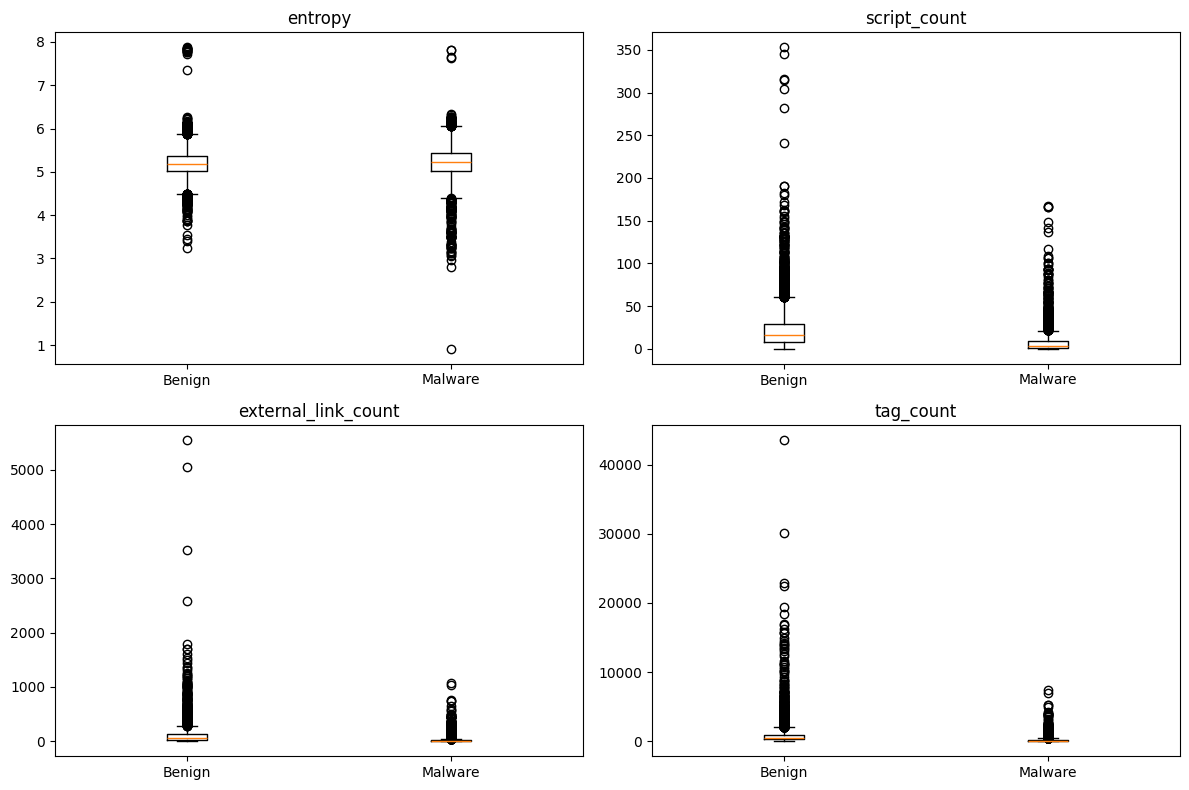

In [ ]:
import matplotlib.pyplot as plt

features_to_check = [
    "entropy",
    "script_count",
    "external_link_count",
    "tag_count"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_check):

    benign = clean_df.loc[clean_df["label"] == 0, feature]
    malware = clean_df.loc[clean_df["label"] == 1, feature]

    ax.boxplot(
        [benign, malware],
        tick_labels=["Benign", "Malware"]
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [ ]:
# Test correlation on HTML structure

javascript_features = [
    'script_count',
    'embedded_js_count',
    'external_js_count',
    'script_entropy',
    'total_script_characters',
    'function_count',
    'eval_in_script_blocks'
]

print(clean_df[javascript_features].corr())

                         script_count  embedded_js_count  external_js_count  \
script_count                 1.000000           0.866671           0.805324   
embedded_js_count            0.866671           1.000000           0.402198   
external_js_count            0.805324           0.402198           1.000000   
script_entropy               0.313975           0.279726           0.243805   
total_script_characters      0.262763           0.289626           0.138056   
function_count               0.165445           0.204701           0.060374   
eval_in_script_blocks        0.082092           0.110446           0.019409   

                         script_entropy  total_script_characters  \
script_count                   0.313975                 0.262763   
embedded_js_count              0.279726                 0.289626   
external_js_count              0.243805                 0.138056   
script_entropy                 1.000000                 0.136030   
total_script_characters    

In [ ]:


def find_skewed_columns(df, threshold=2.0):

    numeric_df = df.select_dtypes(include="number")

    skewness = (
        numeric_df
        .drop(columns=["label"], errors="ignore")
        .skew()
        .sort_values(key=abs, ascending=False)
    )

    skewed_columns = skewness[
        skewness.abs() >= threshold
    ]

    return skewed_columns

In [ ]:
skewed_columns = find_skewed_columns(
    clean_df,
    threshold=2.0
)

print(skewed_columns)

min_link_length             94.008765
mailto_link_count           80.086969
escaped_char_count          71.063947
url_avg_length              61.149347
url_digit_count             53.075006
img_count                   51.920460
url_punct_char_count        51.432801
object_tag_count            48.790194
hex_encoding_rate           42.806207
eval_in_script_blocks       38.467758
max_link_length             36.161239
function_count              28.445886
noscript_count              28.271787
form_count                  26.720703
html_comment_count          23.034030
event_attachment_count      20.518004
redirect_mechanism_count    19.169607
suspicious_word_count       15.040254
base64_string_count         14.902270
external_link_count         12.614194
internal_link_count         11.798489
tag_count                   11.244336
hostname_digit_ratio_avg    10.723442
total_script_characters      9.822593
line_count                   9.043765
file_size                    8.807760
iframe_count

In [ ]:

# Feature Engineering
def calculate_embedded_content_ratio(df):

    embedded = (
        df["embedded_js_count"] +
        df["iframe_count"] +
        df["hidden_iframe_count"] +
        df["object_tag_count"]
    )

    return np.where(
        df["tag_count"] > 0,
        embedded / df["tag_count"],
        0
    )


def calculate_active_content_density(df):

    active = (
        df["script_count"] +
        df["external_js_count"] +
        df["function_count"]
    )

    return np.where(
        df["tag_count"] > 0,
        active / df["tag_count"],
        0
    )
    clean_df["text_size"] = np.where(
    clean_df["file_size"] > 0,
    clean_df["line_count"] / clean_df["file_size"],
    0
)
    clean_df["embedded_objects"] = (
    clean_df["embedded_js_count"] +
    clean_df["iframe_count"] +
    clean_df["hidden_iframe_count"] +
    clean_df["object_tag_count"]
)
    clean_df["active_content_score"] = (
    clean_df["script_count"] +
    clean_df["external_js_count"] +
    clean_df["function_count"]
)
    clean_df["external_reference_count"] = (
    clean_df["external_link_count"] +
    clean_df["external_js_count"]
)
    clean_df["obfuscation_score"] = (
    clean_df["base64_string_count"] +
    clean_df["escaped_char_count"] +
    clean_df["hex_encoding_rate"]
)
    clean_df["structural_complexity_score"] = (
    clean_df["tag_count"] +
    clean_df["max_tag_nesting_depth"] +
    clean_df["unique_tag_count"]
)


clean_df["embedded_content_ratio"] = calculate_embedded_content_ratio(clean_df)

clean_df["active_content_density"] = calculate_active_content_density(clean_df)


/tmp/ipykernel_3221/682095445.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["embedded_content_ratio"] = calculate_embedded_content_ratio(clean_df)
/tmp/ipykernel_3221/682095445.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["active_content_density"] = calculate_active_content_density(clean_df)


In [ ]:
import pandas as pd
import numpy as np

unified_df = pd.DataFrame(index=clean_df.index)

# 1. File characteristics
unified_df["file_size"] = clean_df["file_size"]
#2
unified_df["text_size"] = np.where(
    clean_df["file_size"] > 0,
    clean_df["line_count"] / clean_df["file_size"],
    0
)

# 3. Embedded objects
unified_df["embedded_objects"] = (
    clean_df["embedded_js_count"] +
    clean_df["iframe_count"] +
    clean_df["hidden_iframe_count"] +
    clean_df["object_tag_count"]
)

# 4. Active content
unified_df["active_content_score"] = (
    clean_df["script_count"] +
    clean_df["external_js_count"] +
    clean_df["function_count"]
)
#5
unified_df["active_content_density"] = np.where(
    clean_df["tag_count"] > 0,
    unified_df["active_content_score"] / clean_df["tag_count"],
    0
)

# 6. External references
unified_df["external_reference_count"] = (
    clean_df["external_link_count"] +
    clean_df["external_js_count"]
)

# 7. Obfuscation
unified_df["obfuscation_score"] = (
    clean_df["base64_string_count"] +
    clean_df["escaped_char_count"] +
    clean_df["hex_encoding_rate"]
)

# 8. HTML structure
unified_df["structural_complexity_score"] = (
    clean_df["tag_count"] +
    clean_df["unique_tag_count"] +
    clean_df["max_tag_nesting_depth"]
)

# Label
unified_df["label"] = clean_df["label"]

unified_df

,file_size,text_size,embedded_objects,active_content_score,active_content_density,external_reference_count,obfuscation_score,structural_complexity_score,label
0,2014,0.024330,1,2,0.100000,0,0.0,39,1
1,177022,0.022427,3,9,0.010286,15,2.0,898,0
2,191188,0.016152,17,120,0.108401,349,12.0,1161,0
3,56968,0.040707,1,23,0.025959,15,13.0,924,0
4,167,0.035928,0,0,0.000000,0,0.0,12,1
...,...,...,...,...,...,...,...,...,...
19990,470,0.031915,1,2,0.500000,0,0.0,13,1
19991,30945,0.016093,6,28,0.131455,14,0.0,259,0
19992,174,0.051724,0,0,0.000000,0,0.0,15,1
19994,127751,0.025511,1,13,0.011384,197,25.0,1210,0


In [ ]:

unified_df = unified_df.reset_index(drop=True)


unified_df.to_csv("HTML_unified_features.csv", index=False)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = unified_df.columns.drop("label")

unified_df[cols] = scaler.fit_transform(unified_df[cols])

unified_df

,file_size,text_size,embedded_objects,active_content_score,active_content_density,external_reference_count,obfuscation_score,structural_complexity_score,label
0,0.000255,0.077551,0.002985,0.000145,0.001165,0.000000,0.000000,0.000665,1
1,0.023544,0.071485,0.008955,0.000652,0.000120,0.002698,0.000045,0.020358,0
2,0.025430,0.051483,0.050746,0.008698,0.001263,0.062781,0.000269,0.026388,0
3,0.007568,0.129754,0.002985,0.001667,0.000302,0.002698,0.000292,0.020954,0
4,0.000010,0.114521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000046,1
...,...,...,...,...,...,...,...,...,...
15405,0.000050,0.101729,0.002985,0.000145,0.005824,0.000000,0.000000,0.000069,1
15406,0.004105,0.051297,0.017910,0.002030,0.001531,0.002518,0.000000,0.005709,0
15407,0.000011,0.164871,0.000000,0.000000,0.000000,0.000000,0.000000,0.000115,1
15408,0.016988,0.081315,0.002985,0.000942,0.000133,0.035438,0.000561,0.027511,0


In [ ]:
LOG_COLUMNS = {
    "file_size",
    "line_count",
    "tag_count",
    "script_count",
    "total_script_characters",
    "function_count",
    "form_count",
    "img_count",
    "external_link_count",
    "internal_link_count",
    "external_links_count",
    "base64_string_count",
    "html_comment_count",
    "object_tag_count",
    "event_attachment_count",
    "redirect_mechanism_count"
}

In [ ]:
BINARY_GROUPS = {
}

In [ ]:
HTML_FEATURE_GROUPS = {

    "active_content_score": [

        "script_count",
        "external_js_count"
    ],

    "active_content_density": [

        "active_content_density"
    ],

    "external_reference_count": [

        "external_link_count",
        "mailto_link_count"
    ],

    "file_size": [

        "file_size"
    ],

    "text_size": [

        "line_count"
    ],

    "embedded_content": [

        "embedded_content_ratio",
        "img_count"
    ],

    "obfuscation_score": [

        "entropy",
        "script_entropy",
        "base64_string_count",
        "escaped_char_count",
        "hex_encoding_rate"
    ],

    "structure_complexity_score": [

        "tag_count",
        "unique_tag_count",
        "max_tag_nesting_depth",
        "html_comment_count"
    ]
}

In [ ]:
#split the
X = clean_df.drop(columns=["label"])
y = clean_df["label"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train_grouped = pd.DataFrame(index=X_train.index)
X_test_grouped = pd.DataFrame(index=X_test.index)

group_scalers = {}

In [ ]:
for group_name, columns in HTML_FEATURE_GROUPS.items():

    missing_columns = [
        col for col in columns
        if col not in X_train.columns
    ]

    if missing_columns:
        print(group_name, "missing:", missing_columns)
        continue


    train_values = X_train[columns].copy()
    test_values = X_test[columns].copy()


    # Apply log only to selected FEATURES
    for col in columns:

        if col in LOG_COLUMNS:

            train_values[col] = np.log1p(
                train_values[col].clip(lower=0)
            )

            test_values[col] = np.log1p(
                test_values[col].clip(lower=0)
            )


    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_values)
    test_scaled = scaler.transform(test_values)


    X_train_grouped[group_name] = train_scaled.mean(axis=1)

    X_test_grouped[group_name] = test_scaled.mean(axis=1)


    group_scalers[group_name] = scaler

In [ ]:
X_train_grouped.head()

,active_content_score,active_content_density,external_reference_count,file_size,text_size,embedded_content,obfuscation_score,structure_complexity_score
11498,0.059049,0.001456,0.000000,0.154103,0.250495,0.098684,0.299230,0.033487
17997,0.213449,0.000460,0.292108,0.531401,0.604385,0.088225,0.301666,0.219907
18299,0.347463,0.004583,0.280139,0.670602,0.676393,0.189666,0.346376,0.334972
4119,0.141694,0.000769,0.160791,0.577771,0.711597,0.007448,0.357697,0.224003
6508,0.305077,0.000894,0.234469,0.601959,0.694131,0.203619,0.366335,0.331249


In [ ]:
print("Training shape:", X_train_grouped.shape)
print("Testing shape:", X_test_grouped.shape)

Training shape: (12328, 8)
Testing shape: (3082, 8)


In [ ]:
print("Number of groups:", len(HTML_FEATURE_GROUPS))

Number of groups: 8


In [ ]:
#feature_cols=html_df.columns.drop(['file_path','label'])
#x=html_df[feature_cols]
#y=html_df['label']

#mi_score=mutual_info_classif(x,y,discrete_features='auto')

#mi_df = pd.DataFrame({
   # 'feature': feature_cols,
    #'MI_score': mi_score
#}).sort_values(by='MI_score', ascending=False)

#print(mi_df)

#mi_scores = mutual_info_classif(
    #X_train_grouped,
    #y_train,
   # random_state=42
#)
#print(mi_df)


feature_cols = clean_df.columns.drop(['file_path', 'label'])
X = clean_df[feature_cols]
y = clean_df['label']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mi_score = mutual_info_classif(X_train_full, y_train_full, discrete_features='auto', random_state=42)

mi_df = pd.DataFrame({
    'feature': feature_cols,
    'MI_score': mi_score
}).sort_values(by='MI_score', ascending=False)

print(mi_df)

                     feature  MI_score
33      url_punct_char_count  0.224847
4                  tag_count  0.219059
35   url_avg_subdomain_count  0.214232
1                 line_count  0.208365
26       external_link_count  0.190317
0                  file_size  0.184200
39    embedded_content_ratio  0.172447
34            url_avg_length  0.171452
38           max_link_length  0.171165
16   total_script_characters  0.170780
32           url_digit_count  0.167562
5           unique_tag_count  0.157864
18   keywords_to_words_ratio  0.156781
23         embedded_js_count  0.156668
40    active_content_density  0.153394
6               script_count  0.151760
3             script_entropy  0.149852
19          whitespace_ratio  0.137533
25       internal_link_count  0.120907
30    event_attachment_count  0.112133
28     html_whitespace_ratio  0.101811
15            function_count  0.098987
36  hostname_digit_ratio_avg  0.096346
24         external_js_count  0.086486
27                 img_co

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
model.fit(X_train_grouped, y_train)

y_pred = model.predict(X_test_grouped)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1924
           1       0.84      0.81      0.83      1158

    accuracy                           0.87      3082
   macro avg       0.87      0.86      0.86      3082
weighted avg       0.87      0.87      0.87      3082



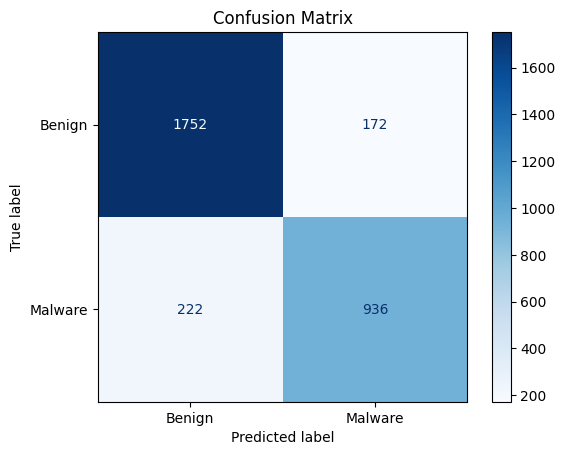

In [ ]:
cm=confusion_matrix(y_test, y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign','Malware'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_full, y_train_full)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
33,url_punct_char_count,0.103832
4,tag_count,0.077395
26,external_link_count,0.061367
6,script_count,0.045651
1,line_count,0.044608
23,embedded_js_count,0.044459
5,unique_tag_count,0.041753
19,whitespace_ratio,0.040048
25,internal_link_count,0.038663
32,url_digit_count,0.033405


In [ ]:
rf_top10 = importance_df.head(10)["feature"].tolist()

print(rf_top10)

['url_punct_char_count', 'tag_count', 'external_link_count', 'script_count', 'line_count', 'embedded_js_count', 'unique_tag_count', 'whitespace_ratio', 'internal_link_count', 'url_digit_count']


In [ ]:
top10_features = mi_df.head(10)["feature"].tolist()

print(top10_features)

['url_punct_char_count', 'tag_count', 'url_avg_subdomain_count', 'line_count', 'external_link_count', 'file_size', 'embedded_content_ratio', 'url_avg_length', 'max_link_length', 'total_script_characters']


In [ ]:
feature_list = html_df.columns.drop(["file_path", "label"])

results_baseline = run_experiment(
    df_input=html_df,
    feature_list=feature_list,
    experiment_name="Baseline",
    test_size=0.2
)

results_baseline

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Experiment,Model,Accuracy,Precision,Recall,F1
0,Baseline,LR,0.58425,0.672622,0.58425,0.523231
1,Baseline,RF,0.94100,0.941099,0.94100,0.940997
2,Baseline,XGB,0.93750,0.937502,0.93750,0.937500


In [ ]:
feature_list = clean_df.columns.drop(["file_path", "label"])

results_clean = run_experiment(
    df_input=clean_df,
    feature_list=feature_list,
    experiment_name="After Cleaning",
    test_size=0.2
)

results_clean

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Experiment,Model,Accuracy,Precision,Recall,F1
0,After Cleaning,LR,0.664179,0.720543,0.561016,0.515073
1,After Cleaning,RF,0.914017,0.910792,0.905004,0.907721
2,After Cleaning,XGB,0.921804,0.918219,0.914507,0.916290
